<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/FlowGraphv2_Multiclass_GATv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch-geometric -q

In [2]:
pip install pandas numpy scikit-learn matplotlib seaborn networkx tqdm

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import subprocess
import sys

def install_local_pyg_dependencies():
    torch_version = torch.__version__.split('+')[0]
    cuda_version = torch.version.cuda

    if cuda_version is None:
        cuda_str = "cpu"
    else:
        cuda_str = "cu" + cuda_version.replace(".", "")

    wheel_url = f"https://data.pyg.org/whl/torch-{torch_version}+{cuda_str}.html"
    print(f"Detected Local PyTorch: {torch_version} | CUDA: {cuda_version}")
    print(f"Fetching Windows wheels from: {wheel_url}\n")

    # On Windows, torch_sparse is highly recommended over pyg_lib
    packages = ["torch_scatter", "torch_sparse"]

    for pkg in packages:
        print(f"Installing {pkg}...")
        try:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", pkg, "-f", wheel_url]
            )
            print(f"Successfully installed {pkg}\n")
        except subprocess.CalledProcessError as e:
            print(f"Failed to install {pkg}. Error: {e}")

install_local_pyg_dependencies()

Detected Local PyTorch: 2.11.0 | CUDA: 12.8
Fetching Windows wheels from: https://data.pyg.org/whl/torch-2.11.0+cu128.html

Installing torch_scatter...

Installing torch_sparse...



In [4]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [5]:
DATASET_DIR = "/Users/balji/OneDrive/GNN_IDS/Balanced_6Class_400K"

files = {
    "BENIGN.csv":0,
    "DDoS.csv":1,
    "DoS.csv":2,
    "Mirai.csv":3,
    "Recon.csv": 4,
    "Spoofing.csv":5
}

dfs = []

for file,label in files.items():

    path = os.path.join(DATASET_DIR,file)
    df = pd.read_csv(path)

    #if file == "BENIGN.csv":
        #df = df.sample(n=160000, random_state=42).reset_index(drop=True)

    df["label"] = label

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

(400000, 87)


In [6]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(400000, 88)


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import numpy as np
import pandas as pd

# 1. Save the keys needed for edge construction BEFORE extracting features
edge_keys = data[['protocol', 'dst_ip', 'dst_port','bidirectional_first_seen_ms']].copy()
edge_keys['node_id'] = np.arange(len(data))

# 2. Explicitly define the TOP features from XGBoost

XGBOOST_TOP_FEATURES = [
 "bidirectional_mean_ps",
    "dst2src_syn_packets",
    "src2dst_min_ps",
    "src2dst_max_piat_ms",
    "dst2src_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_rst_packets",
    "src2dst_max_ps",
    "src2dst_duration_ms",
    "src2dst_bytes",
    "src2dst_ece_packets",
    "bidirectional_max_ps",
    "dst2src_bytes",
    "bidirectional_bytes",
    "dst2src_max_ps",
    "bidirectional_min_ps",
    "bidirectional_syn_packets",
    "dst2src_stddev_ps",
    "bidirectional_ack_packets",
    "bidirectional_mean_piat_ms",
    "dst2src_duration_ms",
    "src2dst_mean_ps",
    "src2dst_min_piat_ms",
    "bidirectional_stddev_ps",
    "src2dst_stddev_piat_ms",
    "bidirectional_cwr_packets",
    "src2dst_psh_packets",
 "ip_version",'dst_ip','protocol'


]

print(f"Using {len(XGBOOST_TOP_FEATURES)} pure statistical features.")

# Convert to numeric and fill NaNs
for col in XGBOOST_TOP_FEATURES:
    data[col] = pd.to_numeric(data[col], errors="coerce")
data[XGBOOST_TOP_FEATURES] = data[XGBOOST_TOP_FEATURES].fillna(0)

# 3. Transductive Split & Isolated Scaling
labels = data["label"].values
idx = np.arange(len(data))

# Split indices first
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=labels)

# Extract only the chosen 27 features
X_raw = data[XGBOOST_TOP_FEATURES].values
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent future-peeking
scaler.fit(X_raw[train_idx])

# Transform all data using the train-derived mean and variance
X_scaled = scaler.transform(X_raw)

# Convert to tensors
X = torch.tensor(X_scaled, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

print(f"X Tensor Shape: {X.shape}") # Should now be [32000, 30]

Using 30 pure statistical features.
X Tensor Shape: torch.Size([400000, 30])


In [8]:
from tqdm import tqdm

print("Grouping nodes by Destination IP, Port, and Protocol...")
# Group the dataset by our target profile
grouped = edge_keys.groupby(['protocol','dst_port', 'dst_ip'])

source_nodes = []
target_nodes = []

print("Executing Temporal Sliding Window (2-second limit)...")
for _, group in tqdm(grouped, desc="Building Temporal Edges"):
    # Ensure the group is sorted by time
    group = group.sort_values('bidirectional_first_seen_ms')

    times = group['bidirectional_first_seen_ms'].values
    nodes = group['node_id'].values
    n = len(times)

    # Optimized two-pointer sliding window
    for i in range(n):
        j = i + 1
        # Look ahead: If the next flow is within 2000 ms, draw an edge
        while j < n and (times[j] - times[i]) <= 2000:
            # Undirected graph requires both directions
            source_nodes.extend([nodes[i], nodes[j]])
            target_nodes.extend([nodes[j], nodes[i]])
            j += 1

# Compile the final edge matrix
edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long)
print(f"\nFinal Temporal edge_index shape: {edge_index.shape}")

Grouping nodes by Destination IP, Port, and Protocol...
Executing Temporal Sliding Window (2-second limit)...


Building Temporal Edges: 100%|██████████| 57299/57299 [00:29<00:00, 1939.54it/s]



Final Temporal edge_index shape: torch.Size([2, 64654556])


In [9]:
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader

# 1. Create Boolean Masks
num_nodes = len(data)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

# 2. Instantiate the pure Flow-to-Flow Graph
graph = Data(x=X, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask)
print("\nFinal Homogeneous Graph Structure:")
print(graph)

# 3. HIGH-PERFORMANCE DATA LOADERS
print("Initializing Multi-Threaded Loaders...")

train_loader = NeighborLoader(
    graph,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=graph.train_mask,
    shuffle=True,
    num_workers=4,           # Utilizing multiple CPU cores
    #pin_memory=True,         # Fast PCIe data transfer
    #persistent_workers=True  # Prevents Windows worker-spawn crashes
)

test_loader = NeighborLoader(
    graph,
    num_neighbors=[15, 10],
    batch_size=2048,
    input_nodes=graph.test_mask,
    shuffle=False,
    num_workers=4,
    #pin_memory=True,
    #persistent_workers=True
)

print(f"Subgraphs to process per epoch: {len(train_loader)}")


Final Homogeneous Graph Structure:
Data(x=[400000, 30], edge_index=[2, 64654556], y=[400000], train_mask=[400000], test_mask=[400000])
Initializing Multi-Threaded Loaders...
Subgraphs to process per epoch: 157


In [10]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class GATModel(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes,
        heads=4
    ):

        super().__init__()

        # First GATv2 Layer
        self.conv1 = GATv2Conv(
            in_channels,
            hidden_channels // heads,
            heads=heads
        )

        # Second GATv2 Layer
        self.conv2 = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn2 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        # Direct classifier
        self.classifier = torch.nn.Linear(
            hidden_channels,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index
    ):

        # Layer 1
        x = self.conv1(
            x,
            edge_index
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.2,
            training=self.training
        )

        # Layer 2
        x = self.conv2(
            x,
            edge_index
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.2,
            training=self.training
        )

        # Classification
        x = self.classifier(x)

        return x

In [17]:

# 1. Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Initialize the model AND move it to the device
model = GATModel(
    in_channels=graph.num_node_features,
    hidden_channels=128,
    num_classes=6,
    heads=4
).to(device) # <--- THIS IS THE CRITICAL MISSING PIECE

# 3. Re-initialize the optimizer since the model parameters just moved to a new device
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.002,
    weight_decay=1e-4
)

#scheduler = torch.optim.lr_scheduler.StepLR(
    #optimizer,
   # step_size=20,
    #gamma=0.5
#)

# 4. Move the loss function to the device

# 6 elements mapping to: [Benign, DDoS, DoS, Mirai, Recon, Spoofing]
weights = torch.tensor(
    [1.0, 2.0, 2.0, 2.0, 2.0, 2.0],
    dtype=torch.float
).to(device)

criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

Using device: cuda


In [18]:
# Assuming model, optimizer, and criterion are initialized and moved to device
def train_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Forward pass on the subgraph
        out = model(batch.x, batch.edge_index)

        # SLICE the output: Only calculate loss for the seed nodes in this batch
        loss = criterion(out[:batch.batch_size], batch.y[:batch.batch_size])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.batch_size

    return total_loss / graph.train_mask.sum().item()

@torch.no_grad()
def evaluate_epoch(loader):
    model.eval()
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # Evaluate only the seed nodes
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        correct += (pred == y_true).sum().item()
        total += batch.batch_size

    return correct / total



In [19]:
# Training Execution
for epoch in range(1, 71):
    loss = train_epoch()
    train_acc = evaluate_epoch(train_loader)

    # We DO NOT evaluate test_acc during training to prevent leakage tweaking.
    # It is kept blind until epoch 50 finishes.

    #scheduler.step()

    print(f"Epoch {epoch:02d} | Loss: {loss:.4f} | Train Acc: {train_acc:.4f}")

# Final Blind Test Evaluation
print("-" * 40)
final_test_acc = evaluate_epoch(test_loader)
print(f"FINAL BLIND TEST ACCURACY: {final_test_acc:.4f}")

#torch.save(model.state_dict(), 'FlowGraph_GATv2.pth')
#print("Model weights successfully saved to disk as 'gat_ids_model_100epochs.pth'")

Epoch 01 | Loss: 1.0188 | Train Acc: 0.7538
Epoch 02 | Loss: 0.8432 | Train Acc: 0.7907
Epoch 03 | Loss: 0.7787 | Train Acc: 0.7857
Epoch 04 | Loss: 0.7328 | Train Acc: 0.7963
Epoch 05 | Loss: 0.6944 | Train Acc: 0.8257
Epoch 06 | Loss: 0.6688 | Train Acc: 0.8300
Epoch 07 | Loss: 0.6466 | Train Acc: 0.8334
Epoch 08 | Loss: 0.6312 | Train Acc: 0.8186
Epoch 09 | Loss: 0.6145 | Train Acc: 0.8419
Epoch 10 | Loss: 0.6046 | Train Acc: 0.8428
Epoch 11 | Loss: 0.5951 | Train Acc: 0.8460
Epoch 12 | Loss: 0.5842 | Train Acc: 0.8483
Epoch 13 | Loss: 0.5750 | Train Acc: 0.8481
Epoch 14 | Loss: 0.5698 | Train Acc: 0.8504
Epoch 15 | Loss: 0.5660 | Train Acc: 0.8520
Epoch 16 | Loss: 0.5577 | Train Acc: 0.8514
Epoch 17 | Loss: 0.5542 | Train Acc: 0.8559
Epoch 18 | Loss: 0.5478 | Train Acc: 0.8587
Epoch 19 | Loss: 0.5460 | Train Acc: 0.8583
Epoch 20 | Loss: 0.5393 | Train Acc: 0.8574
Epoch 21 | Loss: 0.5365 | Train Acc: 0.8614
Epoch 22 | Loss: 0.5320 | Train Acc: 0.8615
Epoch 23 | Loss: 0.5327 | Train 

KeyboardInterrupt: 

Gathering final predictions from the blind test set...

--- Final Test Classification Report ---
              precision    recall  f1-score   support

      Benign     0.8768    0.9356    0.9052     40000
        DDoS     0.9265    0.7520    0.8302      8000
         DoS     0.9992    0.9071    0.9509      8000
       Mirai     0.7912    0.6787    0.7307      8000
       Recon     0.8425    0.8468    0.8446      8000
    Spoofing     0.6761    0.7320    0.7030      8000

    accuracy                         0.8595     80000
   macro avg     0.8521    0.8087    0.8274     80000
weighted avg     0.8620    0.8595    0.8586     80000



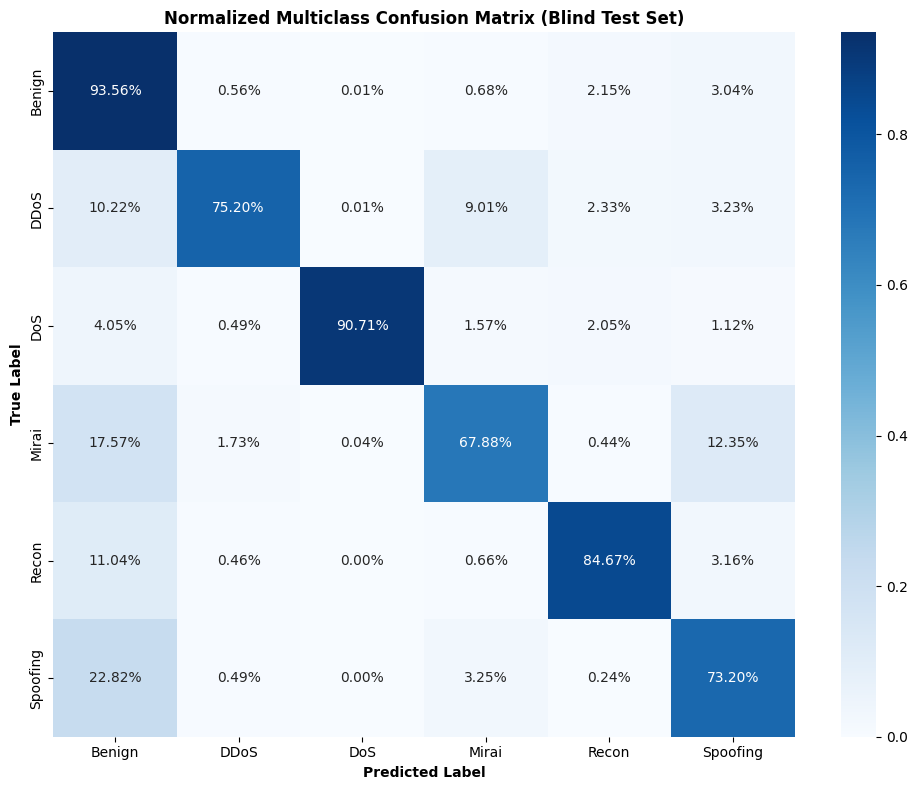

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Gathering final predictions from the blind test set...")

# 1. Extract Predictions and True Labels
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)

        # SLICE: Only evaluate the seed nodes to prevent overlapping evaluations
        pred = out[:batch.batch_size].argmax(dim=1)
        y_true = batch.y[:batch.batch_size]

        all_preds.extend(pred.cpu().numpy())
        all_true.extend(y_true.cpu().numpy())

# Convert to numpy arrays for Scikit-Learn
all_preds = np.array(all_preds)
all_true = np.array(all_true)

# 2. Print the Classification Report
# <--- CHANGED TARGET NAMES --->
target_names = ['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing']

print("\n--- Final Test Classification Report ---")
print(classification_report(all_true, all_preds, target_names=target_names, digits=4))

# 3. Calculate and Plot the Confusion Matrix
cm = confusion_matrix(all_true, all_preds)

# Normalize the matrix row-wise to get percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8)) # Slightly increased figure size for 6 classes
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True
)

plt.xlabel("Predicted Label", fontweight='bold')
plt.ylabel("True Label", fontweight='bold')
plt.title("Normalized Multiclass Confusion Matrix (Blind Test Set)", fontweight='bold')
plt.tight_layout()
plt.show()